# Actividad 6: Análisis de datos de Data Set
## Diego Samuel María González
## Código: 218869748
## Analíticas de datos 2026-B
## 03/09/2026

### Este cuaderno realiza un análisis del conjunto de datos "Datos relacionados con pasantías y salarios 2024", obtenido de Glassdoor.

El conjunto de datos contiene listados de pasantías en ciencia de datos y análisis de datos, incluyendo:

- Company: nombre de la empresa.
- Company Score: calificación de la empresa (escala de 1 a 5).
- Job Title: título de la pasantía.
- Location: ubicación del puesto (ciudad, estado o modalidad remota).
- Salary: rango salarial estimado (por hora o anual).


## 1. Carga de datos:

### En esta sección importamos las librerías necesarias (pandas y numpy) y cargamos el archivo CSV Data_Salaries.csv en un DataFrame de pandas.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

### Posteriormente inspeccionamos las primeras filas para confirmar que la carga fue exitosa y entender la estructura inicial de los datos.

In [2]:
# Ruta del archivo de datos
file_path = 'Data_Salaries.csv'
# Carga del dataset en un DataFrame
data = pd.read_csv(file_path)
# Vista previa de las primeras filas
data.head()

,Company,Company Score,Job Title,Location,Salary
0,PepsiCo,3.9,2025 Summer Intern: R&D,"Plano, TX",$21.50 - $55.40 Per Hour (Employer est.)
1,ghSMART,4.8,Data Engineer Intern,Remote,$20.00 - $30.00 Per Hour (Employer est.)
2,PepsiCo,3.9,2025 Summer Intern: eCommerce Data Science,United States,$21.50 - $40.19 Per Hour (Employer est.)
3,U.S. Bank National Association,3.6,2025 Data Analytics Summer Intern,"Minneapolis, MN",$20.63 - $30.25 Per Hour (Employer est.)
4,Plymouth Rock Assurance,3.4,Fall 2024 Data Science/Predictive Modeler Intern,"Woodbridge, NJ",$77K - $130K (Glassdoor est.)


## 2. Análisis exploratorio de datos:

Antes de limpiar los datos, es necesario entender su estructura: tipos de datos, cantidad de valores nulos, estadísticas descriptivas y valores únicos en las columnas categóricas.

In [3]:
# Información general del DataFrame: tipos de datos y cantidad de valores no nulos
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        648 non-null    str    
 1   Company Score  551 non-null    float64
 2   Job Title      649 non-null    str    
 3   Location       642 non-null    str    
 4   Salary         503 non-null    str    
dtypes: float64(1), str(4)
memory usage: 87.0 KB


In [4]:
# Dimensiones del dataset (filas, columnas)
print(f'Filas: {data.shape[0]}, Columnas: {data.shape[1]}')

# Estadísticas descriptivas de todas las columnas (numéricas y categóricas)
data.describe(include='all')

Filas: 649, Columnas: 5


,Company,Company Score,Job Title,Location,Salary
count,648,551.000000,649,642,503
unique,492,NaN,616,324,364
top,TikTok,NaN,Engineering Intern,United States,$20.00 Per Hour (Employer est.)
freq,14,NaN,6,43,15
mean,NaN,3.739927,NaN,NaN,NaN
std,NaN,0.510012,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,NaN
25%,NaN,3.500000,NaN,NaN,NaN
50%,NaN,3.800000,NaN,NaN,NaN
75%,NaN,4.000000,NaN,NaN,NaN


In [5]:
# Conteo de valores nulos por columna
data.isna().sum()

Company            1
Company Score     98
Job Title          0
Location           7
Salary           146
dtype: int64

In [6]:
# Ejemplos de valores únicos en la columna 'Salary' para entender su formato
print(data['Salary'].dropna().unique()[:15])

# Ejemplos de valores únicos en la columna 'Location'
print(data['Location'].dropna().unique()[:15])

<ArrowStringArray>
['$21.50 - $55.40 Per Hour (Employer est.)', '$20.00 - $30.00 Per Hour (Employer est.)',
 '$21.50 - $40.19 Per Hour (Employer est.)', '$20.63 - $30.25 Per Hour (Employer est.)',
            '$77K - $130K (Glassdoor est.)',             '$36K - $50K (Glassdoor est.)',
            '$72K - $120K (Glassdoor est.)',             '$50K - $67K (Glassdoor est.)',
             '$57K - $86K (Glassdoor est.)',             '$60K - $93K (Glassdoor est.)',
            '$72K - $100K (Glassdoor est.)', '$18.00 - $21.00 Per Hour (Employer est.)',
           '$121K - $204K (Glassdoor est.)',          '$20.00 Per Hour (Employer est.)',
            '$57K - $106K (Glassdoor est.)']
Length: 15, dtype: str
<ArrowStringArray>
[      'Plano, TX',          'Remote',   'United States', 'Minneapolis, MN',  'Woodbridge, NJ',  'Charleston, SC',
    'Waukesha, WI',     'Atlanta, GA',      'Dallas, TX',      'Sewell, NJ',     'Oshkosh, WI',    'Franklin, TN',
    'Moorhead, MN',    'Kennesaw, GA',   

In [7]:
# Distribución de la calificación de las empresas (Company Score)
data['Company Score'].describe()

count    551.000000
mean       3.739927
std        0.510012
min        1.000000
25%        3.500000
50%        3.800000
75%        4.000000
max        5.000000
Name: Company Score, dtype: float64

## 3. Limpieza de datos:

### En esta etapa realizamos los siguientes pasos:

#### 1. Eliminación de filas incompletas: se descartan los registros que no tienen información de Company o Salary, ya que son campos clave para el análisis.

In [8]:
cleaned_data = data.dropna(subset=['Company', 'Salary']).copy()

print(f'Filas antes de limpiar: {data.shape[0]}')
print(f'Filas después de eliminar nulos en Company/Salary: {cleaned_data.shape[0]}')

Filas antes de limpiar: 649
Filas después de eliminar nulos en Company/Salary: 503


#### 2. Extracción del salario: la columna Salary mezcla dos formatos: salario por hora (Per Hour) y salario anual. Usamos expresiones regulares (re) para extraer los valores numéricos mínimo y máximo, y normalizamos todo a una escala anual estimada (asumiendo 40 horas semanales y 52 semanas al año para los salarios por hora).

In [9]:
def parse_salary(salario):
    """Extrae el salario mínimo y máximo (normalizados a escala anual)
    y el tipo original de pago a partir del texto de la columna Salary."""
    if pd.isna(salario):
        return pd.Series([np.nan, np.nan, np.nan])

    texto = str(salario)
    es_por_hora = 'Per Hour' in texto

    # Extraer todos los números (incluyendo decimales) del texto
    numeros = re.findall(r'\d+\.?\d*', texto.replace(',', ''))
    numeros = [float(n) for n in numeros]

    if len(numeros) == 0:
        return pd.Series([np.nan, np.nan, np.nan])
    elif len(numeros) == 1:
        salario_min = salario_max = numeros[0]
    else:
        salario_min, salario_max = numeros[0], numeros[1]

    if es_por_hora:
        # Conversión aproximada a salario anual: 40 hrs/semana x 52 semanas
        salario_min *= 40 * 52
        salario_max *= 40 * 52
        tipo = 'Por Hora'
    else:
        # Los valores anuales están expresados en miles (K)
        salario_min *= 1000
        salario_max *= 1000
        tipo = 'Anual'

    return pd.Series([salario_min, salario_max, tipo])

cleaned_data[['Salario_Min', 'Salario_Max', 'Tipo_Salario']] = cleaned_data['Salary'].apply(parse_salary)

# Salario promedio estimado
cleaned_data['Salario_Promedio'] = (cleaned_data['Salario_Min'] + cleaned_data['Salario_Max']) / 2

cleaned_data[['Salary', 'Salario_Min', 'Salario_Max', 'Tipo_Salario', 'Salario_Promedio']].head(10)

,Salary,Salario_Min,Salario_Max,Tipo_Salario,Salario_Promedio
0,$21.50 - $55.40 Per Hour (Employer est.),44720.0,115232.0,Por Hora,79976.0
1,$20.00 - $30.00 Per Hour (Employer est.),41600.0,62400.0,Por Hora,52000.0
2,$21.50 - $40.19 Per Hour (Employer est.),44720.0,83595.2,Por Hora,64157.6
3,$20.63 - $30.25 Per Hour (Employer est.),42910.4,62920.0,Por Hora,52915.2
4,$77K - $130K (Glassdoor est.),77000.0,130000.0,Anual,103500.0
5,$36K - $50K (Glassdoor est.),36000.0,50000.0,Anual,43000.0
6,$72K - $120K (Glassdoor est.),72000.0,120000.0,Anual,96000.0
7,$50K - $67K (Glassdoor est.),50000.0,67000.0,Anual,58500.0
8,$21.50 - $40.19 Per Hour (Employer est.),44720.0,83595.2,Por Hora,64157.6
9,$57K - $86K (Glassdoor est.),57000.0,86000.0,Anual,71500.0


In [10]:
# Eliminar filas donde no fue posible extraer un salario numérico válido
cleaned_data = cleaned_data.dropna(subset=['Salario_Promedio'])

print(f'Filas después de validar el salario extraído: {cleaned_data.shape[0]}')

Filas después de validar el salario extraído: 503


#### 3. Separación de la ubicación: dividimos la columna Location en Ciudad y Estado cuando es posible.

In [11]:
def parse_location(loc):
    if pd.isna(loc):
        return pd.Series([np.nan, np.nan])
    partes = [p.strip() for p in str(loc).split(',')]
    if len(partes) >= 2:
        return pd.Series([partes[0], partes[1]])
    else:
        # Casos como "Remote" o "United States"
        return pd.Series([partes[0], np.nan])

cleaned_data[['Ciudad', 'Estado']] = cleaned_data['Location'].apply(parse_location)

cleaned_data[['Location', 'Ciudad', 'Estado']].head(10)

,Location,Ciudad,Estado
0,"Plano, TX",Plano,TX
1,Remote,Remote,NaN
2,United States,United States,NaN
3,"Minneapolis, MN",Minneapolis,MN
4,"Woodbridge, NJ",Woodbridge,NJ
5,"Charleston, SC",Charleston,SC
6,"Waukesha, WI",Waukesha,WI
7,"Atlanta, GA",Atlanta,GA
8,United States,United States,NaN
9,"Dallas, TX",Dallas,TX


#### 4. Tratamiento de nulos: para Company Score (numérica) se completa con la mediana; para columnas categóricas restantes con nulos residuales se descartan si son pocas filas.

In [12]:
mediana_score = cleaned_data['Company Score'].median()
cleaned_data['Company Score'] = cleaned_data['Company Score'].fillna(mediana_score)

print(f'Valor usado para rellenar Company Score: {mediana_score}')
cleaned_data['Company Score'].isna().sum()

Valor usado para rellenar Company Score: 3.8


np.int64(0)

#### 5. Eliminación de columnas originales que ya no son necesarias tras la extracción (Salary, Location).

In [13]:
cleaned_data = cleaned_data.drop(columns=['Salary', 'Location'])

# Reordenar columnas para mayor claridad
cleaned_data = cleaned_data[['Company', 'Company Score', 'Job Title', 'Ciudad', 'Estado',
                              'Salario_Min', 'Salario_Max', 'Salario_Promedio', 'Tipo_Salario']]

# Eliminar posibles duplicados
cleaned_data = cleaned_data.drop_duplicates().reset_index(drop=True)

cleaned_data.head(10)

,Company,Company Score,Job Title,Ciudad,Estado,Salario_Min,Salario_Max,Salario_Promedio,Tipo_Salario
0,PepsiCo,3.9,2025 Summer Intern: R&D,Plano,TX,44720.0,115232.0,79976.0,Por Hora
1,ghSMART,4.8,Data Engineer Intern,Remote,NaN,41600.0,62400.0,52000.0,Por Hora
2,PepsiCo,3.9,2025 Summer Intern: eCommerce Data Science,United States,NaN,44720.0,83595.2,64157.6,Por Hora
3,U.S. Bank National Association,3.6,2025 Data Analytics Summer Intern,Minneapolis,MN,42910.4,62920.0,52915.2,Por Hora
4,Plymouth Rock Assurance,3.4,Fall 2024 Data Science/Predictive Modeler Intern,Woodbridge,NJ,77000.0,130000.0,103500.0,Anual
5,Brookfield Properties,3.8,Data Analyst Intern,Charleston,SC,36000.0,50000.0,43000.0,Anual
6,GE HEALTHCARE,4.2,Edison Engineering Program Intern – Software,Waukesha,WI,72000.0,120000.0,96000.0,Anual
7,InComm Payments,3.6,Data Analyst Intern,Atlanta,GA,50000.0,67000.0,58500.0,Anual
8,PepsiCo,3.9,2025 Summer Intern: Commerce Data & Technology,United States,NaN,44720.0,83595.2,64157.6,Por Hora
9,Copart,3.5,Data & AI Intern,Dallas,TX,57000.0,86000.0,71500.0,Anual


In [14]:
# Verificación final del dataset limpio
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           503 non-null    str    
 1   Company Score     503 non-null    float64
 2   Job Title         503 non-null    str    
 3   Ciudad            497 non-null    str    
 4   Estado            419 non-null    str    
 5   Salario_Min       503 non-null    float64
 6   Salario_Max       503 non-null    float64
 7   Salario_Promedio  503 non-null    float64
 8   Tipo_Salario      503 non-null    str    
dtypes: float64(4), str(5)
memory usage: 72.5 KB


In [15]:
# Guardar el dataset limpio en un nuevo archivo CSV
cleaned_data.to_csv('resultado_2.csv', index=False)
print('Archivo "resultado_2.csv" guardado correctamente.')

Archivo "resultado_2.csv" guardado correctamente.


## 4. Generación de resultados
Con el dataset ya limpio, generamos indicadores y resúmenes que respondan preguntas de interés:

#### ¿Cuál es el salario promedio general de las pasantías?

In [16]:
# Recargar el dataset limpio desde el archivo generado (buena práctica para asegurar reproducibilidad)
resultados = pd.read_csv('resultado_2.csv')

# Estadísticas generales del salario promedio
resultados['Salario_Promedio'].describe()

count       503.000000
mean      58433.704970
std       26738.064248
min        1000.000000
25%       41600.000000
50%       52000.000000
75%       72000.000000
max      163280.000000
Name: Salario_Promedio, dtype: float64


#### ¿Qué empresas ofrecen los mejores salarios promedio?

In [17]:
# Top 10 empresas con mejor salario promedio ofrecido (con al menos 1 registro)
top_empresas = (resultados.groupby('Company')['Salario_Promedio']
                 .mean()
                 .sort_values(ascending=False)
                 .head(10))
top_empresas

Company
Stonersville F.C. Flames    163280.0
CALSTART                    162500.0
Walter P Moore              152500.0
Tabyt                       150000.0
Michigan State Athletics    143500.0
Dover Food Retail           140400.0
Wells Fargo                 131500.0
Gwinnett County             129500.0
ConocoPhillips              126500.0
Taft Museum of Art          126500.0
Name: Salario_Promedio, dtype: float64


#### ¿Cómo varía el salario según el estado?

In [18]:
# Salario promedio por estado (Top 10 estados con más ofertas)
estados_top = resultados['Estado'].value_counts().head(10).index
salario_por_estado = (resultados[resultados['Estado'].isin(estados_top)]
                       .groupby('Estado')['Salario_Promedio']
                       .mean()
                       .sort_values(ascending=False))
salario_por_estado

Estado
VA    71419.120000
NJ    61713.760000
NY    61671.080000
OH    59770.050000
FL    58723.750000
TX    58717.085714
GA    58658.640000
IL    56082.211765
MA    55150.588235
CA    49588.564706
Name: Salario_Promedio, dtype: float64


#### ¿Cuáles son los títulos de pasantía más comunes?

In [19]:
# Títulos de pasantía más frecuentes
resultados['Job Title'].value_counts().head(10)

Job Title
Engineering Intern                                  5
Data Analyst Intern                                 4
Research Intern                                     3
Geospatial Data Analyst Internship                  3
Digital Marketing Intern                            3
Diversity Outreach Intern (Remote)                  2
Data Analytics Intern                               2
Business Development Intern                         2
Diversity and Equity Initiatives Intern (Remote)    2
Sales Intern                                        2
Name: count, dtype: int64

In [20]:
# Correlación entre la calificación de la empresa (Company Score) y el salario promedio
correlacion = resultados[['Company Score', 'Salario_Promedio']].corr()
correlacion

,Company Score,Salario_Promedio
Company Score,1.000000,0.010998
Salario_Promedio,0.010998,1.000000



#### ¿Existe relación entre la calificación de la empresa y el salario ofrecido?

In [21]:
# Comparación entre pasantías pagadas por hora vs. de forma anual
resumen_tipo_salario = resultados.groupby('Tipo_Salario')['Salario_Promedio'].agg(['count', 'mean', 'min', 'max'])
resumen_tipo_salario

,count,mean,min,max
Tipo_Salario,,,,
Anual,236,66118.644068,1000.0,162500.0
Por Hora,267,51641.024719,16640.0,163280.0


## 5. Graficación:

Visualizamos los resultados obtenidos mediante matplotlib para facilitar su interpretación:

#### Histograma de la distribución del salario promedio.

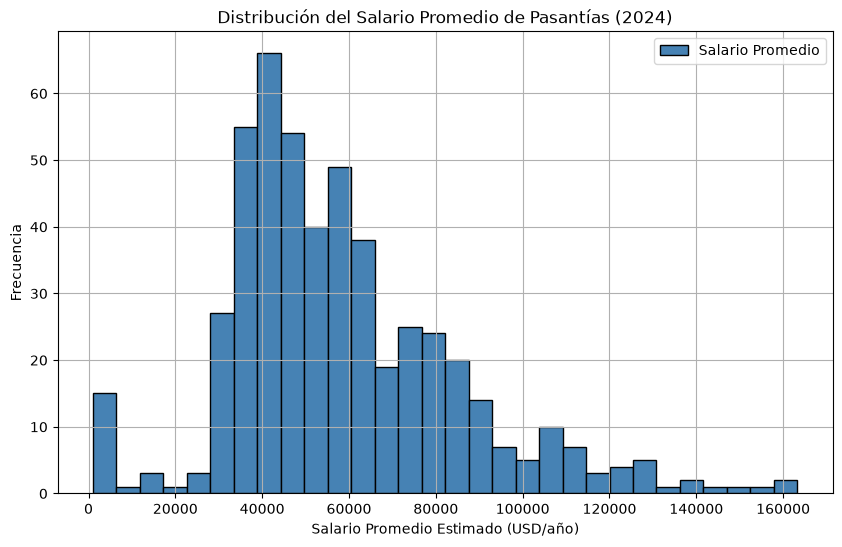

In [22]:
# Recargar los datos limpios para la sección de graficación
data_to_plot = pd.read_csv('resultado_2.csv')

#Histograma de la distribución del salario promedio
plt.figure(figsize=(10, 6))
plt.hist(data_to_plot['Salario_Promedio'], bins=30, color='steelblue', edgecolor='black', label='Salario Promedio')
plt.title('Distribución del Salario Promedio de Pasantías (2024)')
plt.xlabel('Salario Promedio Estimado (USD/año)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.show()


#### Gráfico de barras con las 10 empresas mejor pagadas.

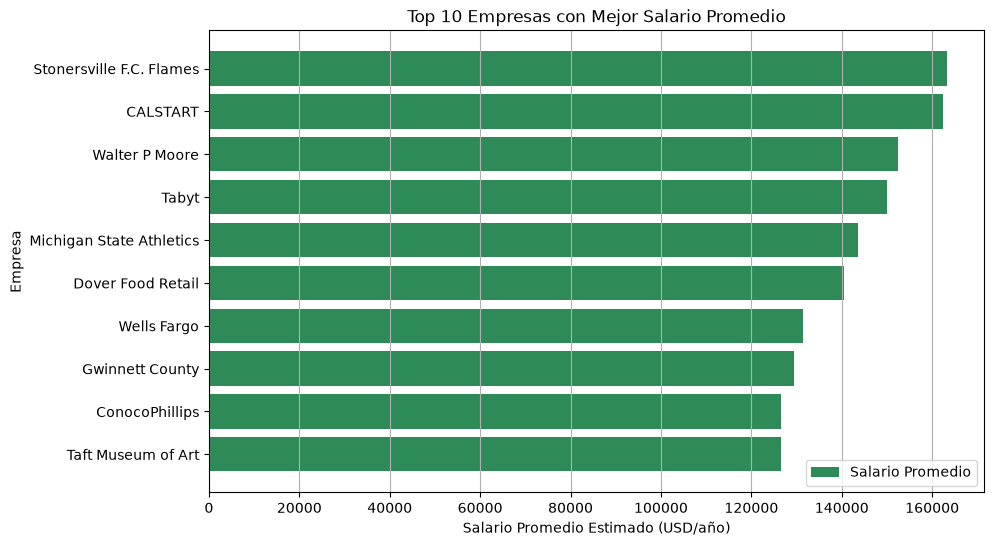

In [23]:
#Top 10 empresas con mejor salario promedio
top10_empresas = (data_to_plot.groupby('Company')['Salario_Promedio']
                   .mean()
                   .sort_values(ascending=False)
                   .head(10))

plt.figure(figsize=(10, 6))
plt.barh(top10_empresas.index[::-1], top10_empresas.values[::-1], color='seagreen', label='Salario Promedio')
plt.title('Top 10 Empresas con Mejor Salario Promedio')
plt.xlabel('Salario Promedio Estimado (USD/año)')
plt.ylabel('Empresa')
plt.legend()
plt.grid(True, axis='x')
plt.show()


#### Gráfico de barras del salario promedio por estado.

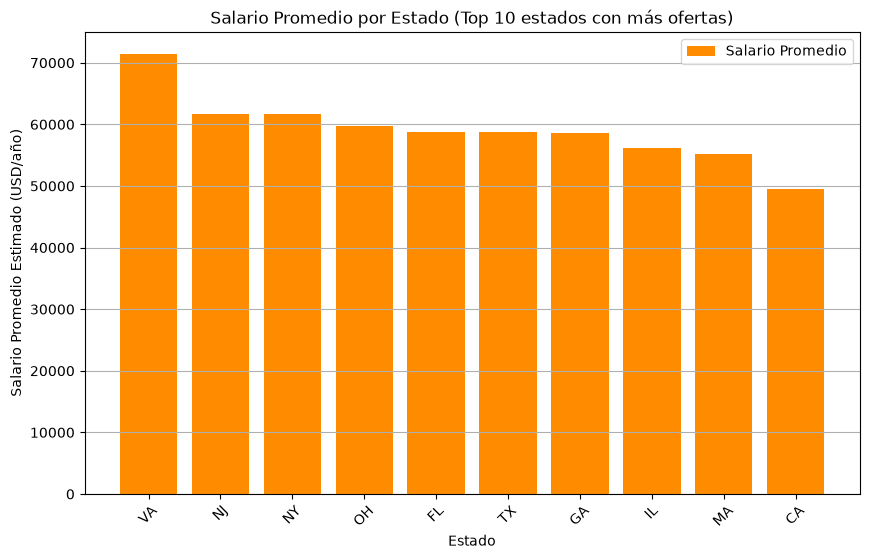

In [24]:
#Salario promedio por estado (Top 10 estados con más ofertas)
plt.figure(figsize=(10, 6))
plt.bar(salario_por_estado.index, salario_por_estado.values, color='darkorange', label='Salario Promedio')
plt.title('Salario Promedio por Estado (Top 10 estados con más ofertas)')
plt.xlabel('Estado')
plt.ylabel('Salario Promedio Estimado (USD/año)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, axis='y')
plt.show()


#### Diagrama de dispersión entre la calificación de la empresa y el salario.

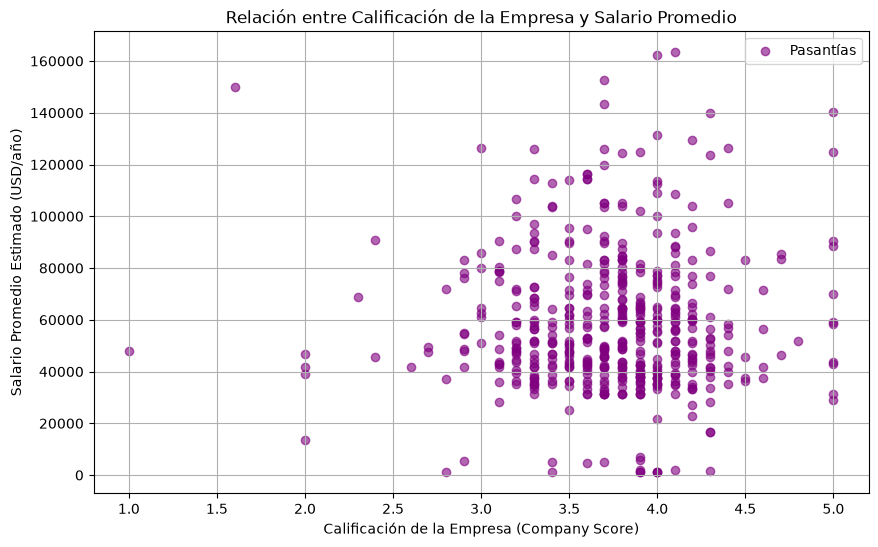

In [25]:
#Relación entre la calificación de la empresa y el salario promedio
plt.figure(figsize=(10, 6))
plt.scatter(data_to_plot['Company Score'], data_to_plot['Salario_Promedio'],
            alpha=0.6, color='purple', label='Pasantías')
plt.title('Relación entre Calificación de la Empresa y Salario Promedio')
plt.xlabel('Calificación de la Empresa (Company Score)')
plt.ylabel('Salario Promedio Estimado (USD/año)')
plt.legend()
plt.grid(True)
plt.show()